Episode 0, Avg Reward: -1.00
Episode 1000, Avg Reward: -0.38
Episode 2000, Avg Reward: -0.36
Episode 3000, Avg Reward: -0.31
Episode 4000, Avg Reward: -0.29
Episode 5000, Avg Reward: -0.34
Episode 6000, Avg Reward: -0.27
Episode 7000, Avg Reward: -0.24
Episode 8000, Avg Reward: -0.31
Episode 9000, Avg Reward: -0.23
Episode 10000, Avg Reward: -0.26
Episode 11000, Avg Reward: -0.26
Episode 12000, Avg Reward: -0.21
Episode 13000, Avg Reward: -0.19
Episode 14000, Avg Reward: -0.18
Episode 15000, Avg Reward: -0.17
Episode 16000, Avg Reward: -0.14
Episode 17000, Avg Reward: -0.14
Episode 18000, Avg Reward: -0.16
Episode 19000, Avg Reward: -0.11
Episode 20000, Avg Reward: -0.19
Episode 21000, Avg Reward: -0.15
Episode 22000, Avg Reward: -0.16
Episode 23000, Avg Reward: -0.18
Episode 24000, Avg Reward: -0.13
Episode 25000, Avg Reward: -0.08
Episode 26000, Avg Reward: -0.16
Episode 27000, Avg Reward: -0.07
Episode 28000, Avg Reward: -0.11
Episode 29000, Avg Reward: -0.13
Episode 30000, Avg Rewa

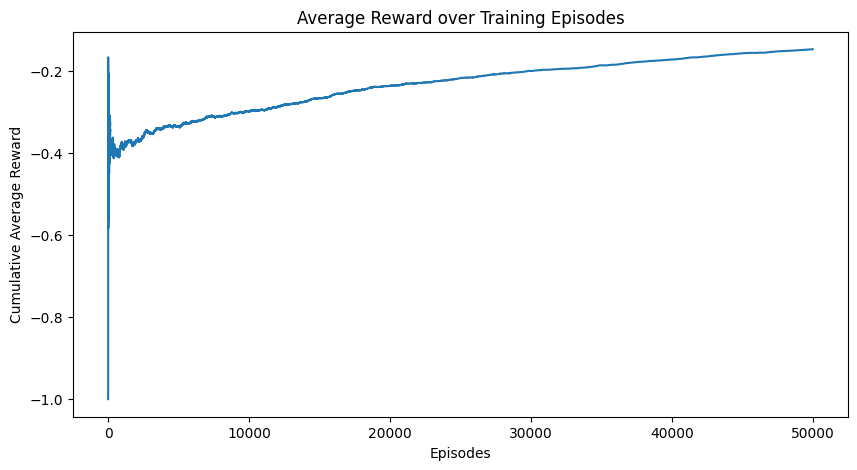

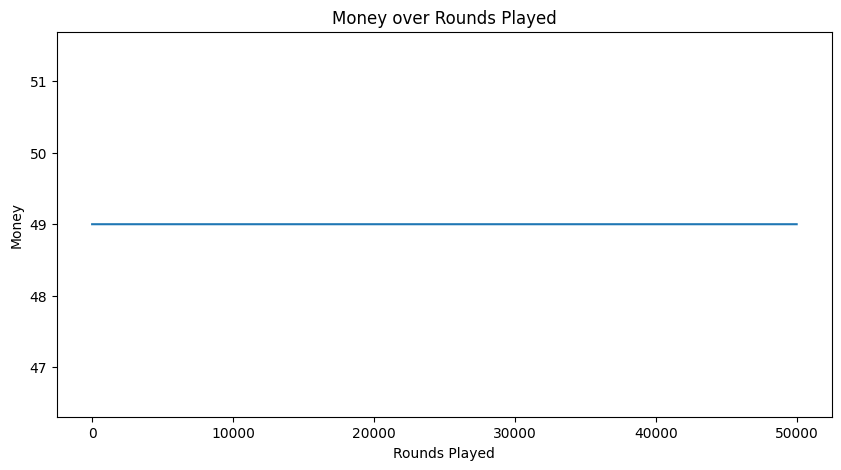

In [4]:
import numpy as np
from collections import defaultdict
import gymnasium as gym
import matplotlib.pyplot as plt

class BlackjackQLearningAgent:
    def __init__(self, learning_rate=0.1, discount_factor=0.95, epsilon=1.0, epsilon_decay=0.99995, min_epsilon=0.01):
        self.q_values = defaultdict(lambda: np.zeros(2))
        self.lr = learning_rate
        self.gamma = discount_factor
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.min_epsilon = min_epsilon

    def get_action(self, state):
        # Epsilon-greedy action selection
        if np.random.random() < self.epsilon:
            action = np.random.choice([0, 1])
        else:
            action = np.argmax(self.q_values[state])
        
        # Decay epsilon
        self.epsilon = max(self.min_epsilon, self.epsilon * self.epsilon_decay)
        return action

    def update(self, state, action, reward, next_state, done):
        # Q-learning update rule
        current_q = self.q_values[state][action]
        if done:
            target_q = reward
        else:
            target_q = reward + self.gamma * np.max(self.q_values[next_state])
        
        self.q_values[state][action] += self.lr * (target_q - current_q)

class BlackjackEnv(gym.Env):
    def __init__(self, render_mode=None, natural=False, sab=False, total_decks=5):
        self.action_space = gym.spaces.Discrete(2)
        self.observation_space = gym.spaces.Tuple(
            (gym.spaces.Discrete(32), gym.spaces.Discrete(11), gym.spaces.Discrete(2))
        )
        self.natural = natural
        self.sab = sab
        self.render_mode = render_mode
        self.running_count = 0
        self.betting_unit = 1
        self.money = 50
        self.current_bet = 1
        one_suite = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 10, 10, 10]
        self.original_deck = one_suite * 4 * total_decks
        self.deck = self.original_deck.copy()

    def step(self, action):
        assert self.action_space.contains(action)
        if action:
            self.player.append(self.draw_card(self.np_random))
            if self.is_bust(self.player):
                terminated = True
                reward = -1.0
            else:
                terminated = False
                reward = 0.0
        else:
            terminated = True
            while self.sum_hand(self.dealer) < 17:
                self.dealer.append(self.draw_card(self.np_random))
            reward = self.cmp(self.score(self.player), self.score(self.dealer))
            if self.sab and self.is_natural(self.player) and not self.is_natural(self.dealer):
                reward = 1.0
            elif not self.sab and self.natural and self.is_natural(self.player) and reward == 1.0:
                reward = 1.5

        self.money += reward * self.current_bet
        return self._get_obs(), reward, terminated, self.money

    def _get_obs(self):
        return (self.sum_hand(self.player), self.dealer[0], int(self.usable_ace(self.player)))


    def reset(self, seed=None):
        super().reset(seed=seed)
        self.money = 50
        self.deck = self.original_deck.copy()
        self.running_count = 0
        return self.new_round()

    def new_round(self):
        self.dealer = self.draw_hand(self.np_random)
        self.player = self.draw_hand(self.np_random)
        return self._get_obs()

    def draw_card(self, np_random):
        if len(self.deck) == 0:
            print("Deck is empty! Reshuffling...")
            self.deck = self.original_deck.copy()  # Reshuffle if empty
        card_index = np_random.choice(len(self.deck))
        card = self.deck[card_index]
        if card in [1, 10]:
            self.running_count -= 1
        elif 2 <= card <= 6:
            self.running_count += 1
        self.deck.pop(card_index)
        return card


    def draw_hand(self, np_random):
        return [self.draw_card(np_random), self.draw_card(np_random)]

    def getRemainingDecks(self):
        return round(len(self.deck) / 52 * 2) / 2

    @staticmethod
    def cmp(a, b):
        return float(a > b) - float(a < b)

    @staticmethod
    def usable_ace(hand):
        return 1 in hand and sum(hand) + 10 <= 21

    @staticmethod
    def sum_hand(hand):
        if BlackjackEnv.usable_ace(hand):
            return sum(hand) + 10
        return sum(hand)

    @staticmethod
    def is_bust(hand):
        return BlackjackEnv.sum_hand(hand) > 21

    @staticmethod
    def score(hand):
        return 0 if BlackjackEnv.is_bust(hand) else BlackjackEnv.sum_hand(hand)

    @staticmethod
    def is_natural(hand):
        return sorted(hand) == [1, 10]

def train_agent(env, agent, num_episodes=50000):
    episode_rewards = []
    
    for episode in range(num_episodes):
        # Reset environment for each episode
        state = env.reset()
        total_episode_reward = 0
        done = False
        
        while not done:
            # Select and take action
            action = agent.get_action(state)
            next_state, reward, done, money = env.step(action)
            
            # Update Q-values
            agent.update(state, action, reward, next_state, done)
            
            # Update state and track reward
            state = next_state
            total_episode_reward += reward
        
        episode_rewards.append(total_episode_reward)
        
        # Print progress
        if episode % 1000 == 0:
            print(f"Episode {episode}, Avg Reward: {np.mean(episode_rewards[-1000:]):.2f}")
    
    return episode_rewards

def evaluate_agent(env, agent, num_episodes=10000):
    total_rewards = []
    
    for _ in range(num_episodes):
        state = env.reset()
        episode_reward = 0
        done = False
        
        while not done:
            # Use greedy policy for evaluation
            action = np.argmax(agent.q_values[state])
            state, reward, done, _ = env.step(action)
            episode_reward += reward
        
        total_rewards.append(episode_reward)
    
    return np.mean(total_rewards)

# Main execution
def main():
    # Create environment with some specific parameters
    env = BlackjackEnv(natural=True, sab=True, total_decks=5)
    
    # Initialize agent
    agent = BlackjackQLearningAgent()
    
    # Train agent
    training_rewards = train_agent(env, agent)
    
    # Evaluate agent
    avg_reward = evaluate_agent(env, agent)
    print(f"Average Reward during Evaluation: {avg_reward:.2f}")
    
    # Visualize training progress
    plt.figure(figsize=(10, 5))
    plt.plot(np.cumsum(training_rewards) / np.arange(1, len(training_rewards) + 1))
    plt.title('Average Reward over Training Episodes')
    plt.xlabel('Episodes')
    plt.ylabel('Cumulative Average Reward')
    plt.show()

    # Plot money over rounds played
    plt.figure(figsize=(10, 5))
    plt.plot(range(len(training_rewards)), [env.money for _ in range(len(training_rewards))])
    plt.title('Money over Rounds Played')
    plt.xlabel('Rounds Played')
    plt.ylabel('Money')
    plt.show()

if __name__ == "__main__":
    main()